In [2]:
# Core scverse libraries
from __future__ import annotations

import anndata as ad

# Data retrieval
import pooch
import scanpy as sc

In [3]:
sc.set_figure_params(dpi=50, facecolor="white")

In [4]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("./"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

In [5]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata

/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.14/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64


/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.14/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.14/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

In [6]:
adata.var_names

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1',
       ...
       'AC133551.1', 'AC136612.1', 'AC136616.1', 'AC136616.3', 'AC136616.2',
       'AC141272.1', 'AC023491.2', 'AC007325.1', 'AC007325.4', 'AC007325.2'],
      dtype='object', length=36601)

In [7]:
adata.obs

,sample
AAACCCAAGGATGGCT-1,s1d1
AAACCCAAGGCCTAGA-1,s1d1
AAACCCAAGTGAGTGC-1,s1d1
AAACCCACAAGAGGCT-1,s1d1
AAACCCACATCGTGGC-1,s1d1
...,...
TTTGTTGAGAGTCTGG-1,s1d3
TTTGTTGCAGACAATA-1,s1d3
TTTGTTGCATGTTACG-1,s1d3
TTTGTTGGTAGTCACT-1,s1d3


In [8]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [9]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

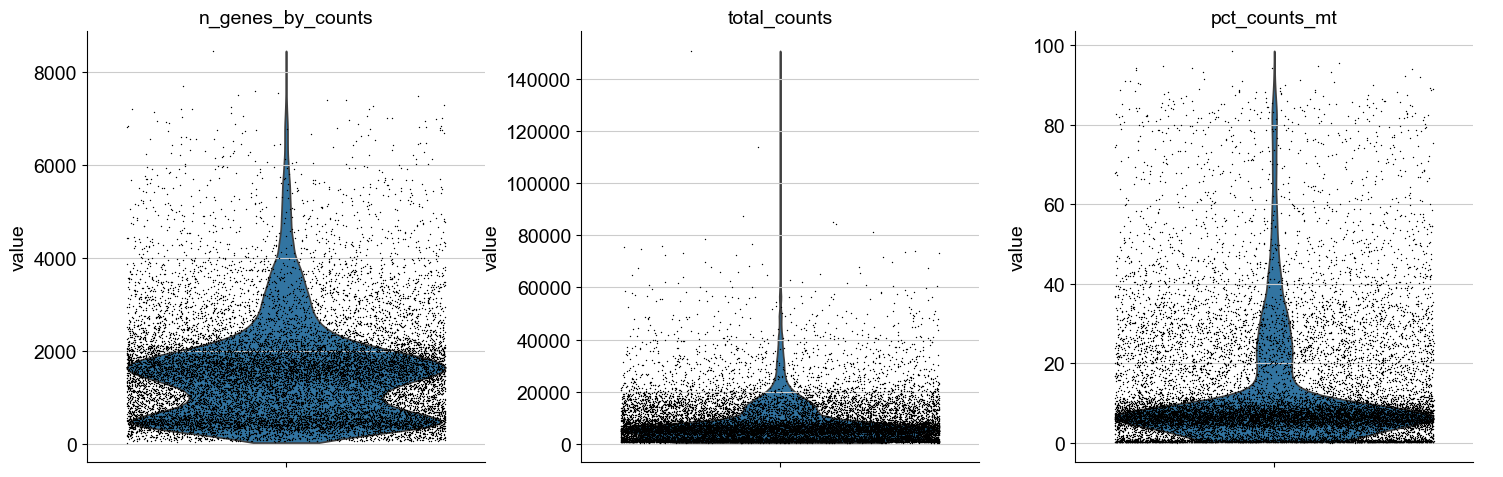

In [10]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

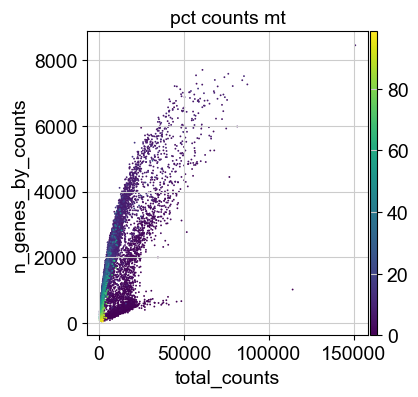

In [11]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [14]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [15]:
adata = adata[adata.obs.pct_counts_mt < 10, :]

In [19]:
adata

adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 21406024 stored elements and shape (11716, 23427)>

In [17]:
sc.pp.scrublet(adata, batch_key="sample")

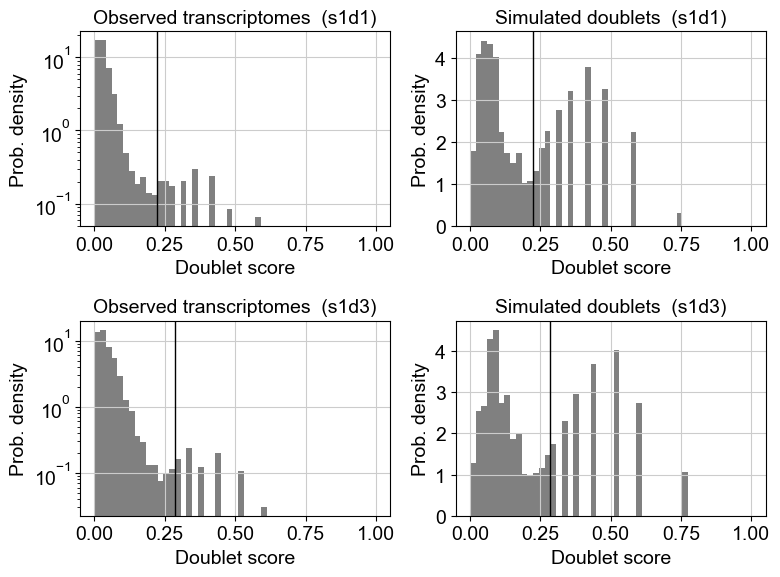

In [18]:
sc.pl.scrublet_score_distribution(adata)

In [20]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [21]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [22]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

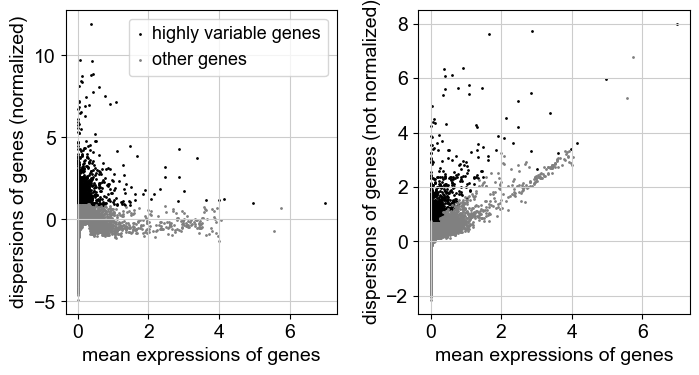

In [23]:
sc.pl.highly_variable_genes(adata)

In [24]:
sc.tl.pca(adata)

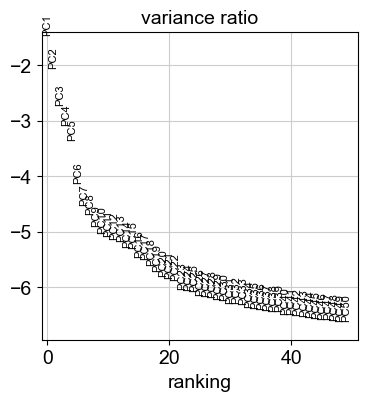

In [25]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

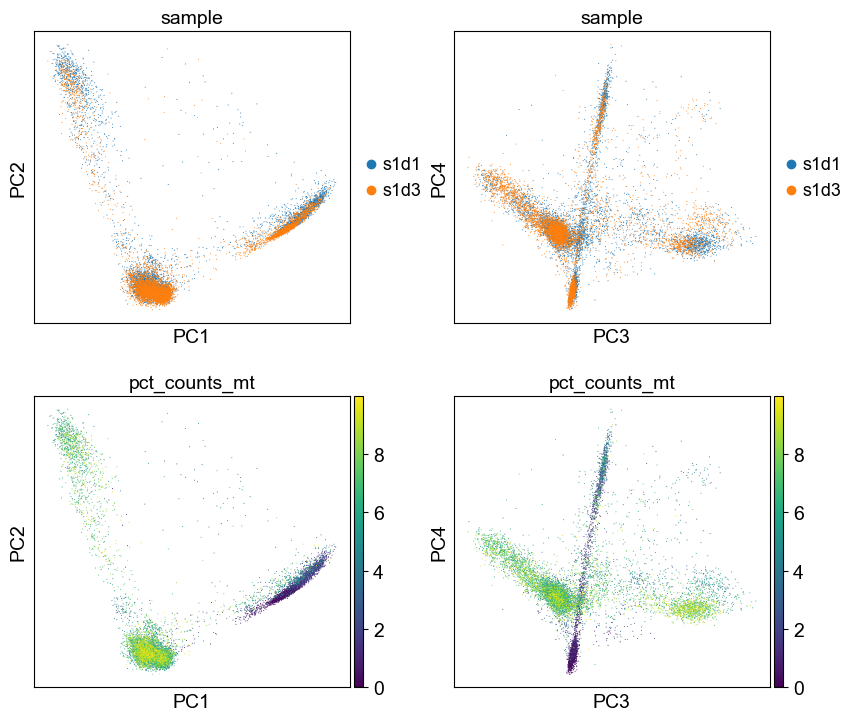

In [26]:
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [27]:
sc.pp.neighbors(adata)

In [28]:
sc.tl.umap(adata)

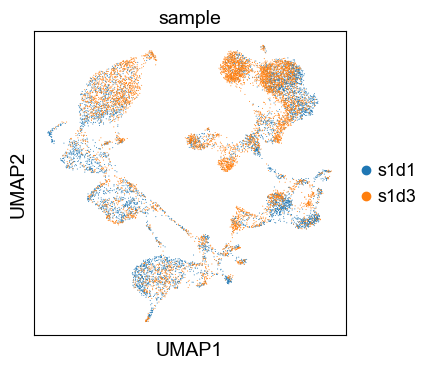

In [29]:
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [30]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster,
# especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

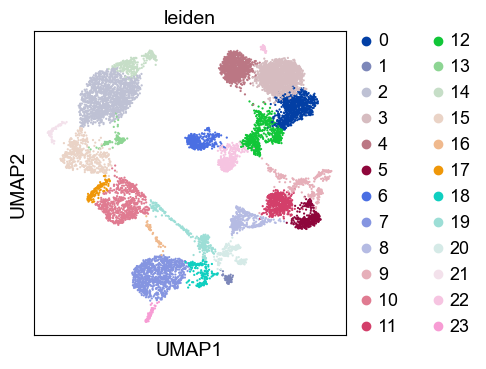

In [31]:
sc.pl.umap(adata, color=["leiden"])

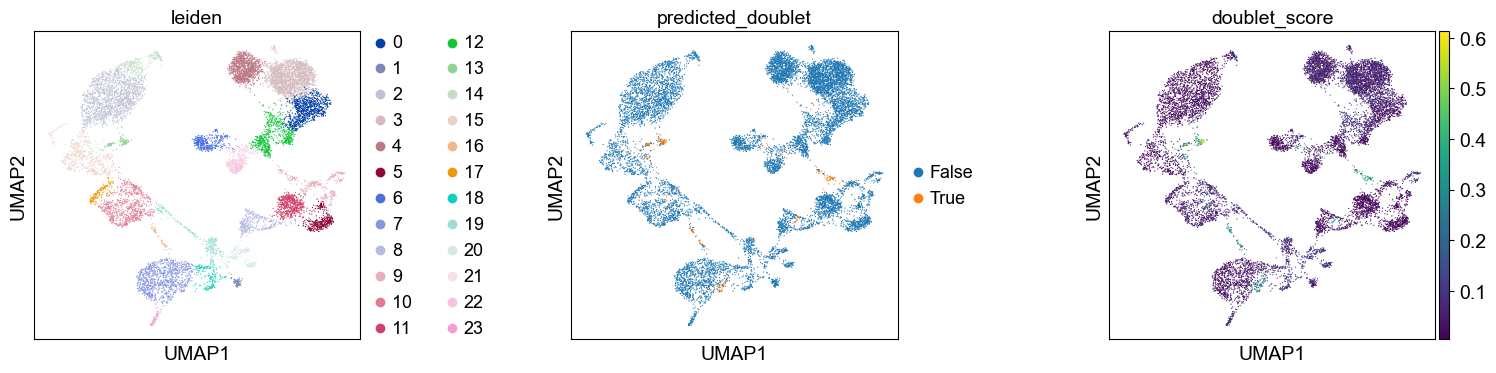

In [32]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

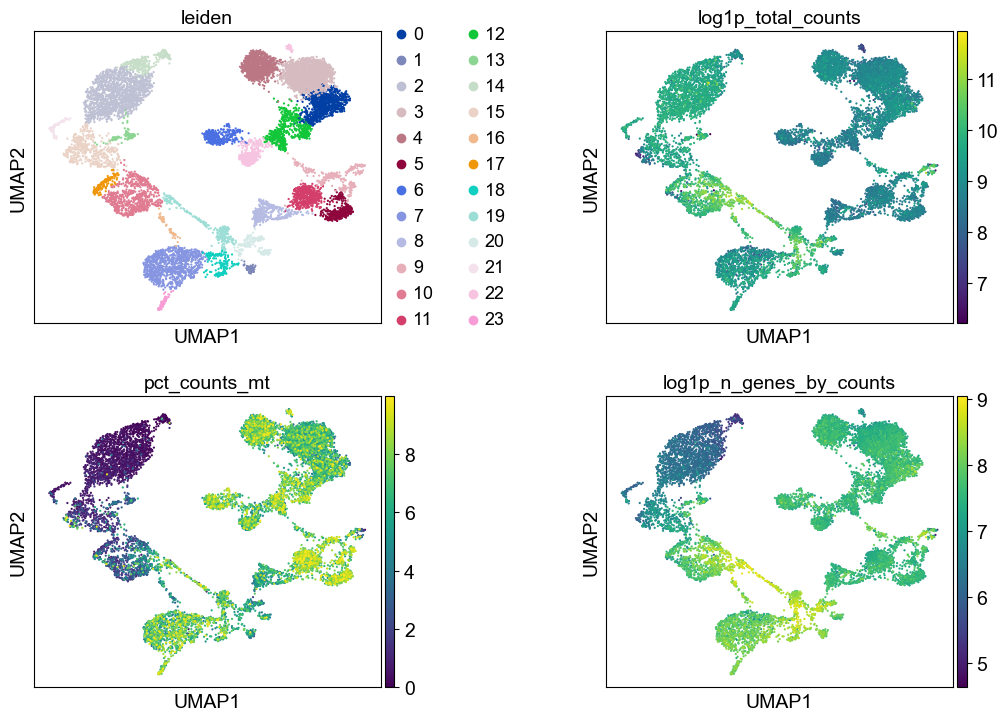

In [33]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

In [34]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

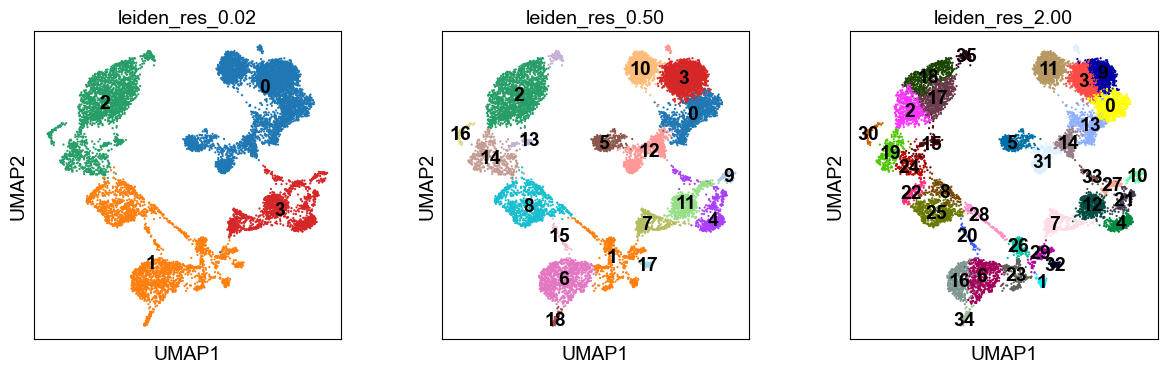

In [35]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

In [36]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

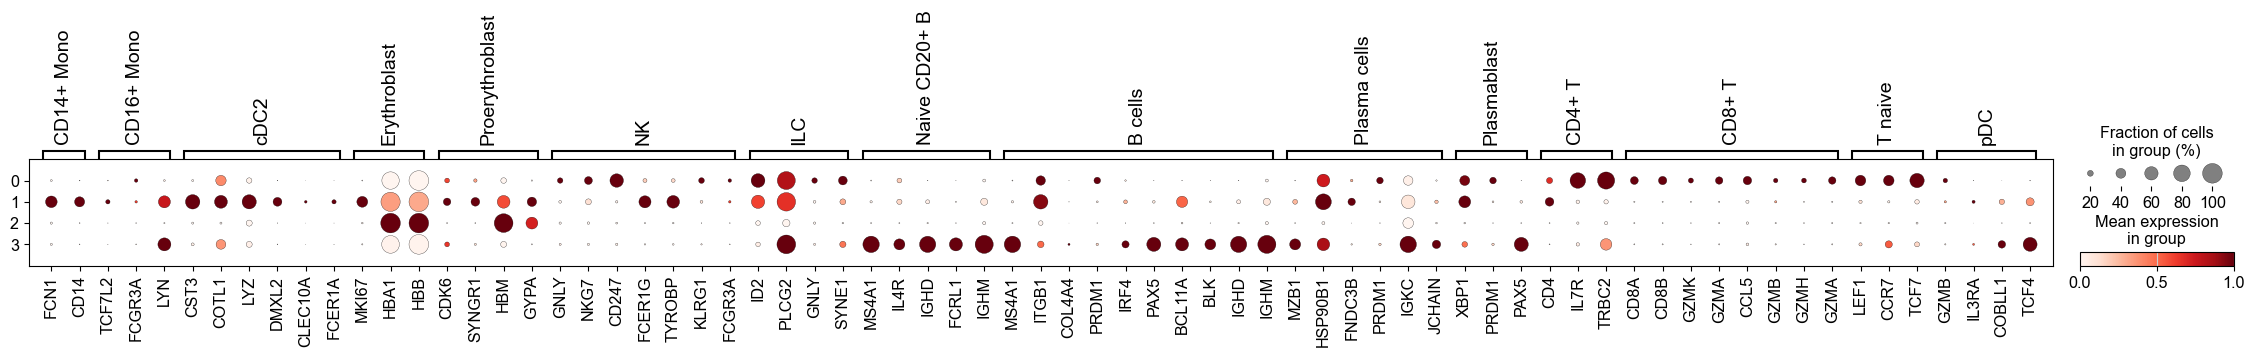

In [44]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.02", standard_scale="var")

In [45]:
adata.obs["cell_type_lvl1"] = adata.obs["leiden_res_0.02"].map(
    {
        "0": "CD4+T",
        "1": "cDC2",
        "2": "Erythroblast",
        "3": "B Cells",
    }
)

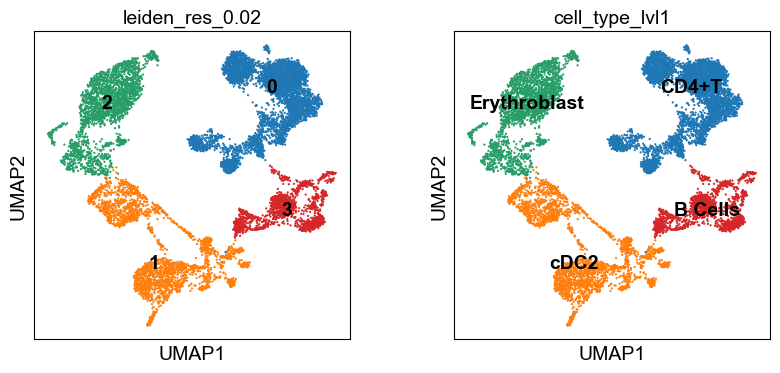

In [46]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "cell_type_lvl1"],
    legend_loc="on data",
)

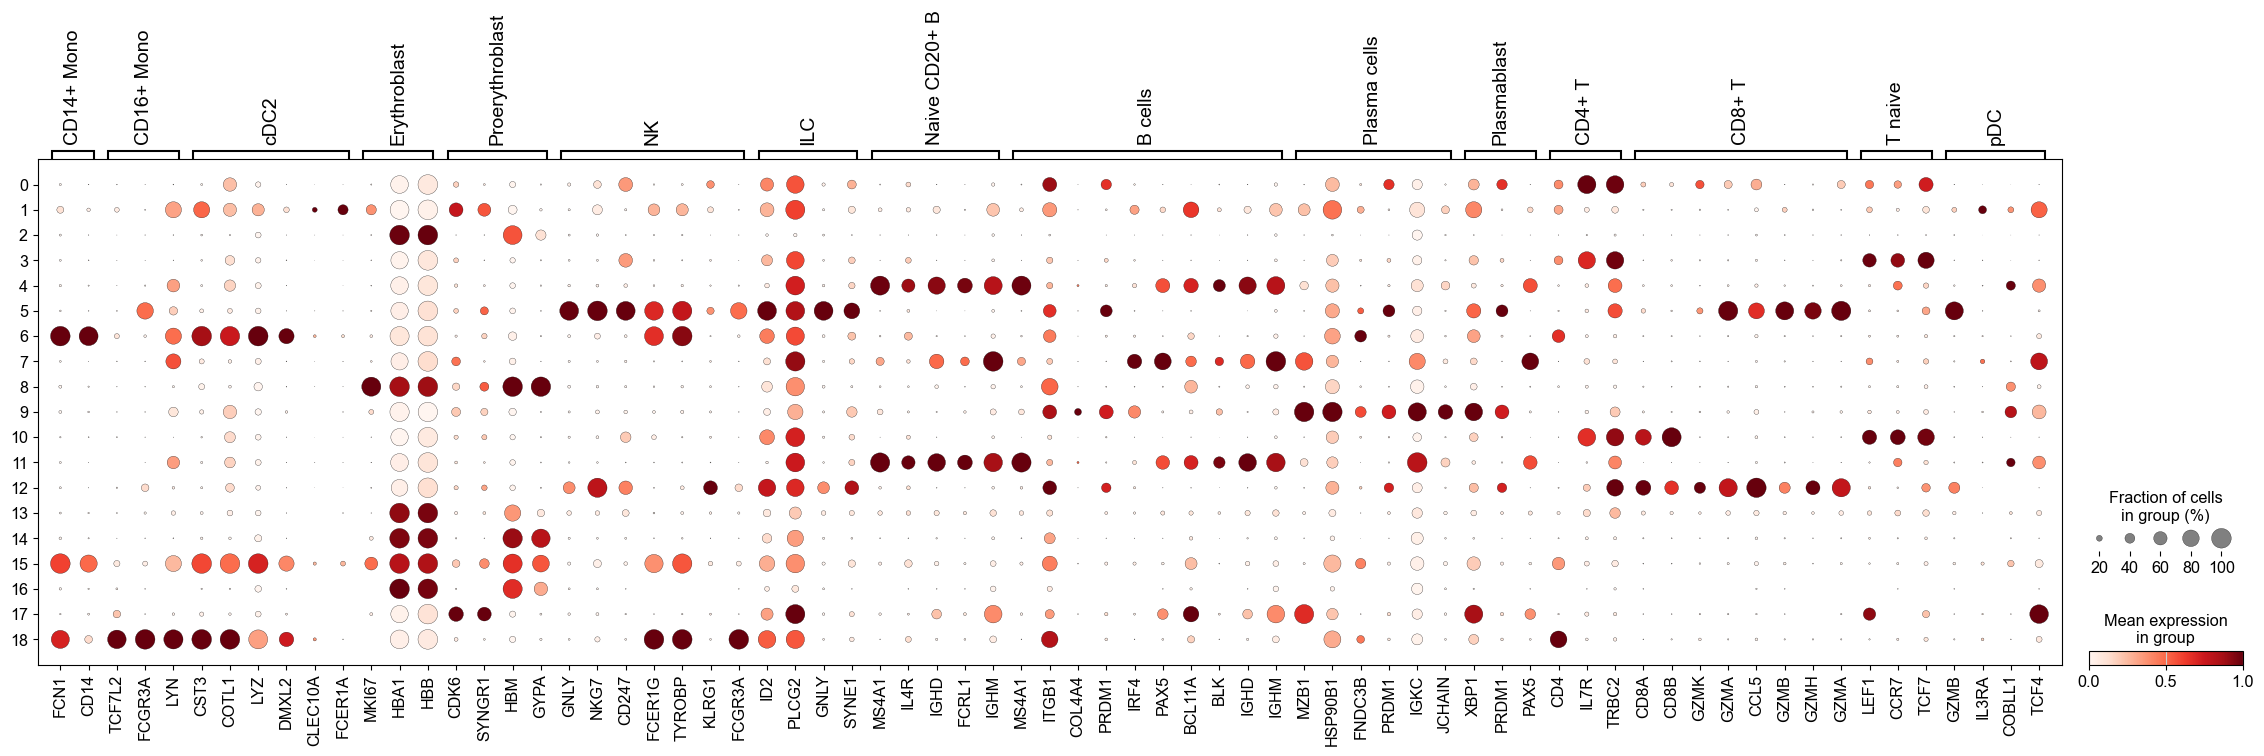

In [38]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.50", standard_scale="var")

In [ ]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.50", method="wilcoxon")

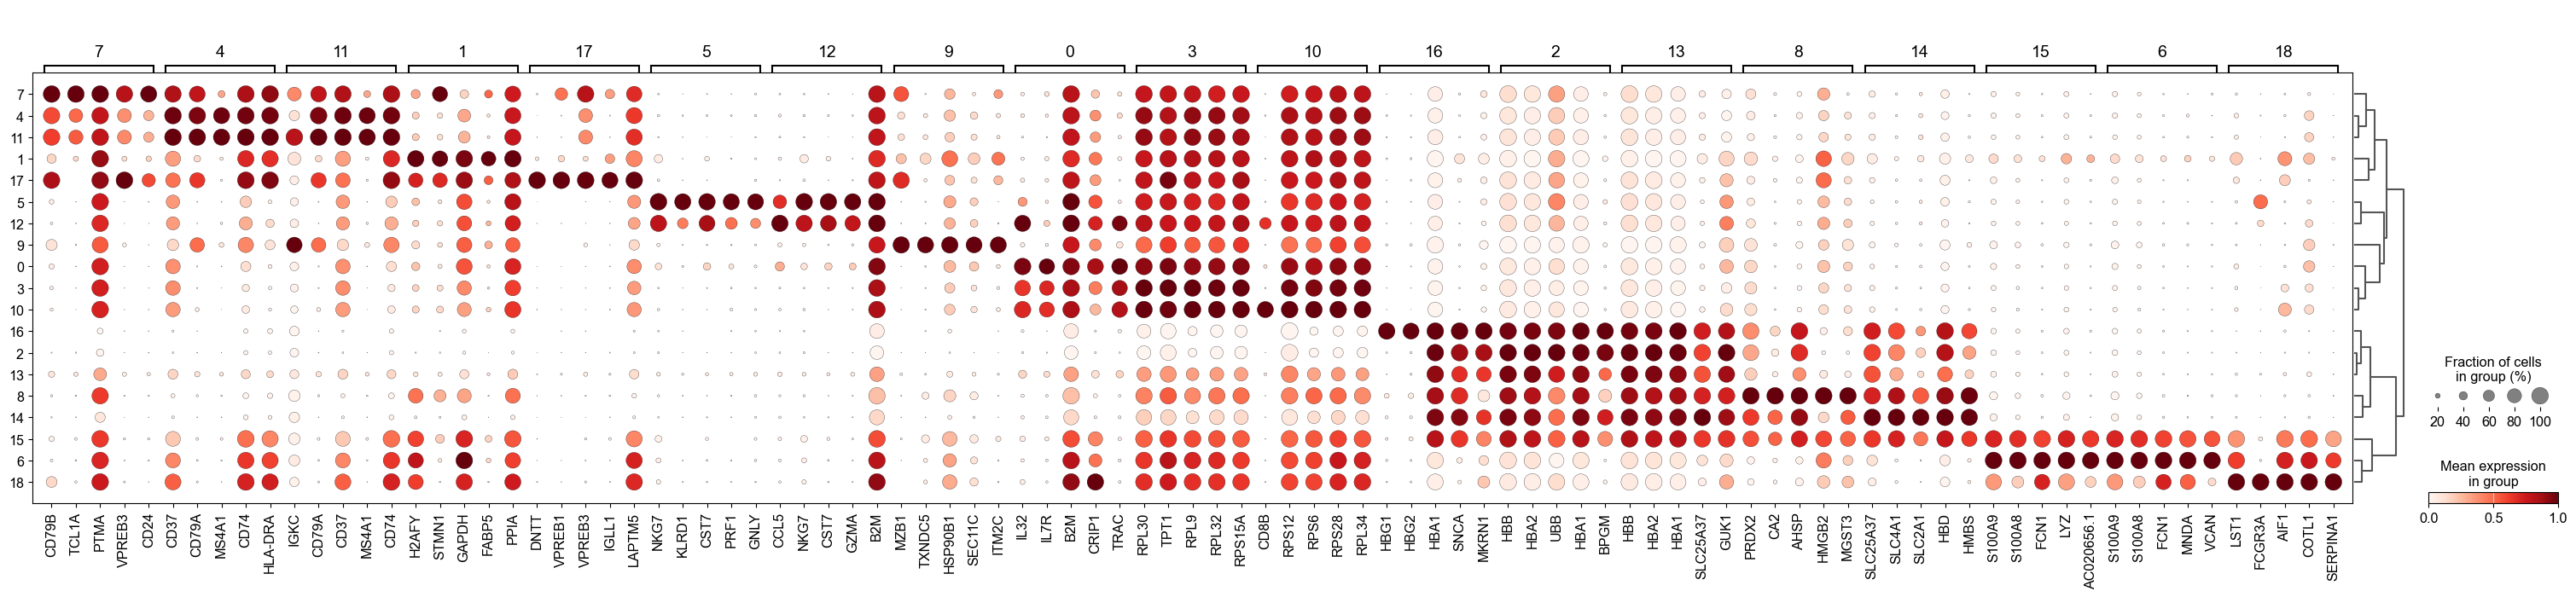

In [40]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_res_0.50", standard_scale="var", n_genes=5)

In [41]:
sc.get.rank_genes_groups_df(adata, group="7").head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CD79B,31.631578,5.977178,1.359075e-219,3.183906e-215
1,TCL1A,31.022215,6.416398,2.704704e-211,3.168155e-207
2,PTMA,30.274397,2.451758,2.491401e-201,1.945535e-197
3,VPREB3,30.241030,5.675845,6.845438e-201,4.009202e-197
4,CD24,30.006910,5.982350,7.974210e-198,3.736236e-194


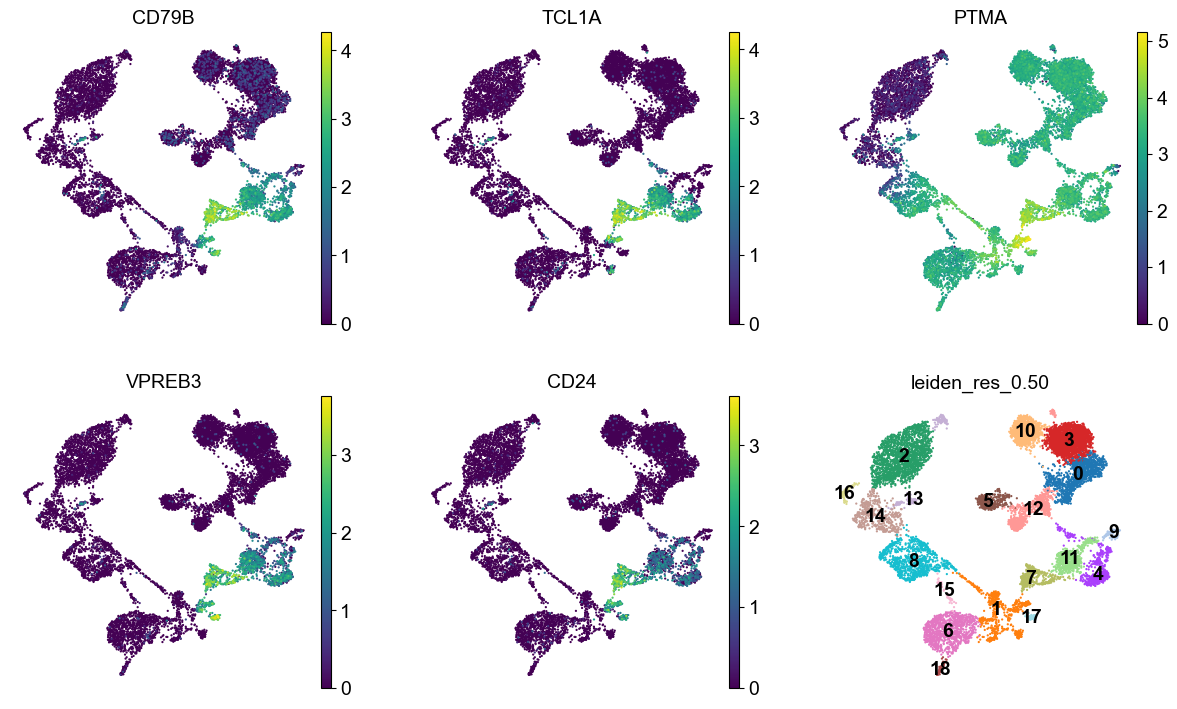

In [42]:
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group="7").head(5)["names"]
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, "leiden_res_0.50"],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)

In [47]:
adata.obs["cell_type_lvl2"] = adata.obs["leiden_res_0.50"].map(
    {
        "7": "B cells"
    }
)

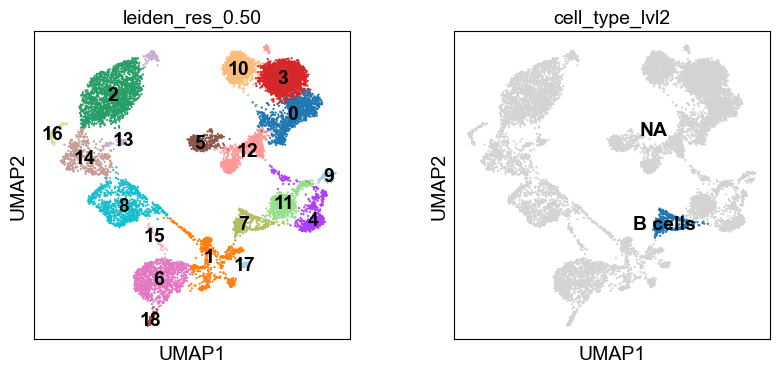

In [48]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.50", "cell_type_lvl2"],
    legend_loc="on data",
)

In [ ]:
# from cell_annotator import CellAnnotator

# cell_ann = CellAnnotator(
#     adata, species="human", tissue="bone marrow mononuclear cells", cluster_key="leiden_res_0.50", 
#     provider="gemini",
# ).annotate_clusters()

##get gemini api key from akshay and add in .env file and load it here

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
0,A1CF,False,Hepatocytes,Endoderm,True,0.189189,0.004437,True,0.175000,0.000257,9606,Liver,0.002
1,A2APA5,False,Germ cells,Mesoderm,False,0.000000,0.000000,True,0.432927,0.000000,10090,Reproductive,0.004
2,A2M,True,Bergmann glia,Ectoderm,True,0.000000,0.062343,True,0.333333,0.001604,9606,Brain,0.012
3,A3FIN4,False,Mast cells,Mesoderm,False,0.000000,0.000000,True,0.184211,0.000708,10090,Immune system,0.001
4,A4GALT,True,Mast cells,Mesoderm,True,0.000000,0.014133,True,0.000000,0.003023,9606,Immune system,0.005
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8206,ZNF521,False,Adipocyte progenitor cells,Mesoderm,True,0.000000,0.010338,False,0.000000,0.000000,9606,Connective tissue,0.002
8207,ZNRF4,False,Germ cells,Mesoderm,True,0.284360,0.000000,True,0.000000,0.000000,9606,Reproductive,0.010
8208,ZPBP2,True,Germ cells,Mesoderm,True,0.436019,0.000000,True,0.000000,0.000000,9606,Reproductive,0.008


In [ ]:
#using decoupler
import decoupler as dc

markers = dc.op.resource("PanglaoDB", organism="human")
markers

In [60]:
# Filter by canonical_marker and human
markers = markers[
    markers["human"].astype(bool)
    & markers["canonical_marker"].astype(bool)
    & (markers["human_sensitivity"].astype(float) > 0.5)
]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Format
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]
markers

,source,target
,,
18,Pulmonary alveolar type II cells,ABCA3
90,Enterocytes,ACSL5
105,Smooth muscle cells,ACTA2
113,Smooth muscle cells,ACTG2
114,Myoepithelial cells,ACTG2
...,...,...
8092,Endothelial cells,VWF
8101,Luminal epithelial cells,WFDC2
8102,Ductal cells,WFDC2


In [61]:
dc.mt.ulm(data=adata, net=markers, tmin=3)

In [62]:
adata.obsm["score_ulm"]

,Acinar cells,Adipocytes,Alpha cells,Astrocytes,B cells,B cells naive,Basal cells,Beta cells,Cholangiocytes,Delta cells,...,Pancreatic stellate cells,Pericytes,Plasma cells,Plasmacytoid dendritic cells,Platelets,Podocytes,Proximal tubule cells,Pulmonary alveolar type II cells,Smooth muscle cells,T cells
AAACCCAAGGATGGCT-1,-0.983645,0.176561,1.151466,-0.777534,3.662724,5.359661,-0.425805,-0.737616,-0.650487,-0.425805,...,-0.337606,2.166592,1.137196,1.806679,5.251134,-1.099848,-0.886585,-0.737616,-0.737616,18.910591
AAACCCACAAGAGGCT-1,-1.414509,-0.653087,0.073371,-1.118107,8.884946,10.025091,-0.612309,-1.060704,-0.935408,1.230332,...,-1.224883,2.101079,8.450789,18.362708,5.132445,-0.737938,-1.000235,-0.486909,-0.156820,4.763549
AAACCCAGTCCGCAGT-1,0.677581,-0.332536,-0.235108,-0.303549,0.469093,0.663543,-0.166236,-0.287966,-0.253951,-0.166236,...,-0.332536,-0.235108,0.117081,-0.371810,2.519269,-0.429376,-0.346122,-0.287966,-0.287966,-0.384012
AAACGAAAGCAATTCC-1,-0.913776,-0.249521,0.669910,-0.722306,3.397160,5.017019,-0.395561,-0.685224,-0.604284,-0.395561,...,-0.791282,1.815765,1.330730,1.372733,3.732788,-1.021725,-0.823611,-0.685224,-0.685224,18.703793
AAACGAACAAGAATAC-1,-0.909775,0.519065,0.874018,-0.719143,23.519829,26.997213,-0.393829,-0.682224,-0.601638,-0.393829,...,-0.787817,2.054519,11.250745,3.518693,5.359102,-0.510996,-0.820004,-0.682224,-0.682224,8.846523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTCTCACAA-1,-0.642061,0.088408,-0.650038,-0.839272,-0.308483,-1.187182,-0.459615,-0.796185,-0.459044,-0.459615,...,-0.919419,-0.650038,-0.652569,-0.594569,2.279553,-0.715594,-0.956983,-0.796185,-0.796185,0.230809
TTTGGTTTCCGTCCTA-1,-0.932774,0.711395,0.751021,-0.737323,1.849240,4.181286,-0.403784,-0.699470,-0.616847,-0.403784,...,-0.807733,2.059027,-1.042967,1.509237,4.517718,-0.584525,-0.840734,-0.699470,-0.699470,14.147876
TTTGTTGCAGACAATA-1,-1.345150,-0.082787,1.010459,-0.668189,2.965190,0.662217,-0.582287,-1.008694,-0.889542,-0.582287,...,-1.164823,2.697831,1.989875,1.899522,7.209606,-0.279103,-0.519329,-1.008694,-0.083611,0.845982
TTTGTTGCATGTTACG-1,-0.626952,-0.116787,-0.622359,-0.803535,-0.530929,-0.943818,-0.440044,-0.762283,-0.672240,-0.440044,...,-0.880268,-0.622359,-0.439656,-0.761627,1.218859,-1.136628,-0.916233,-0.762283,-0.762283,0.124122


In [63]:
score = dc.pp.get_obsm(adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 11716 × 47
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0.02', 'leiden_res_0.50', 'leiden_res_2.00', 'cell_type_lvl1', 'cell_type_lvl2', 'pseudo_batch'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'sample_colors', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'predicted_doublet_colors', 'leiden_res_0.02', 'leiden_res_0.50', 'leiden_res_2.00', 'leiden_res_0.02_colors', 'leiden_res_0.50_colors', 'leiden_res_2.00_colors', 'rank_genes_groups', 'dendrogram_leiden_res_0.50', 'cell_type_lvl1_colors', 'cell_type_lvl2_colo

In [67]:
score.obs.columns

Index(['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score',
       'predicted_doublet', 'leiden', 'leiden_res_0.02', 'leiden_res_0.50',
       'leiden_res_2.00', 'cell_type_lvl1', 'cell_type_lvl2', 'pseudo_batch'],
      dtype='object')

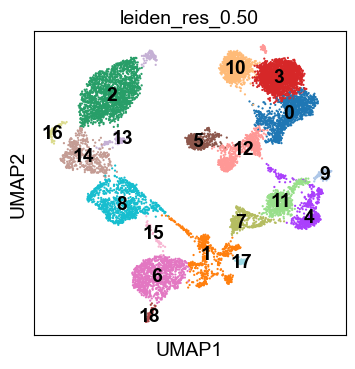

In [81]:
sc.pl.umap(score, color=["leiden_res_0.50"], legend_loc="on data")

In [75]:
df = dc.tl.rankby_group(adata=score, groupby="leiden_res_0.50", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
0,0,rest,T cells,50.425066,10.534607,3.684068e-317,1.731512e-315
1,0,rest,Fibroblasts,23.986960,1.719597,3.155799e-110,7.416127e-109
2,0,rest,Pericytes,22.488406,0.956781,3.865672e-100,6.056220e-99
3,0,rest,Platelets,22.443589,1.556797,6.916197e-100,8.126532e-99
5,0,rest,Ductal cells,20.271466,0.690046,8.317548e-84,6.515412e-83
...,...,...,...,...,...,...,...
884,18,rest,B cells,2.470174,1.932717,1.560454e-02,1.880547e-02
886,18,rest,Pulmonary alveolar type II cells,2.269089,0.190069,2.537615e-02,2.908973e-02
888,18,rest,Germ cells,0.599613,0.094042,5.497653e-01,6.009063e-01
891,18,rest,Oligodendrocyte progenitor cells,0.279907,0.038710,7.799944e-01,7.969508e-01


In [76]:
n_ctypes = 3
ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()
ctypes_dict

/var/folders/yp/rq67n9wd35vfkdbx07pvj2k80000gp/T/ipykernel_19535/777748877.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()


{'0': ['T cells', 'Fibroblasts', 'Pericytes'],
 '1': ['Pericytes', 'Hepatic stellate cells', 'Fibroblasts'],
 '10': ['T cells', 'Pericytes', 'Neurons'],
 '11': ['B cells naive', 'B cells', 'Plasma cells'],
 '12': ['NK cells', 'Gamma delta T cells', 'Platelets'],
 '13': ['Erythroid-like and erythroid precursor cells',
  'Enteroendocrine cells',
  'Basal cells'],
 '14': ['Enterocytes',
  'Erythroid-like and erythroid precursor cells',
  'Acinar cells'],
 '15': ['Neutrophils', 'Monocytes', 'Macrophages'],
 '16': ['Erythroid-like and erythroid precursor cells',
  'Enteroendocrine cells',
  'Enterocytes'],
 '17': ['Endothelial cells', 'B cells', 'Mesangial cells'],
 '18': ['Hepatocytes', 'Macrophages', 'Dendritic cells'],
 '2': ['Erythroid-like and erythroid precursor cells',
  'Enteroendocrine cells',
  'Basal cells'],
 '3': ['T cells', 'Pericytes', 'Neurons'],
 '4': ['B cells', 'B cells naive', 'Plasma cells'],
 '5': ['Gamma delta T cells', 'NK cells', 'Beta cells'],
 '6': ['Neutrophils',

categories: 0, 1, 2, etc.
var_group_labels: 0, 1, 10, etc.


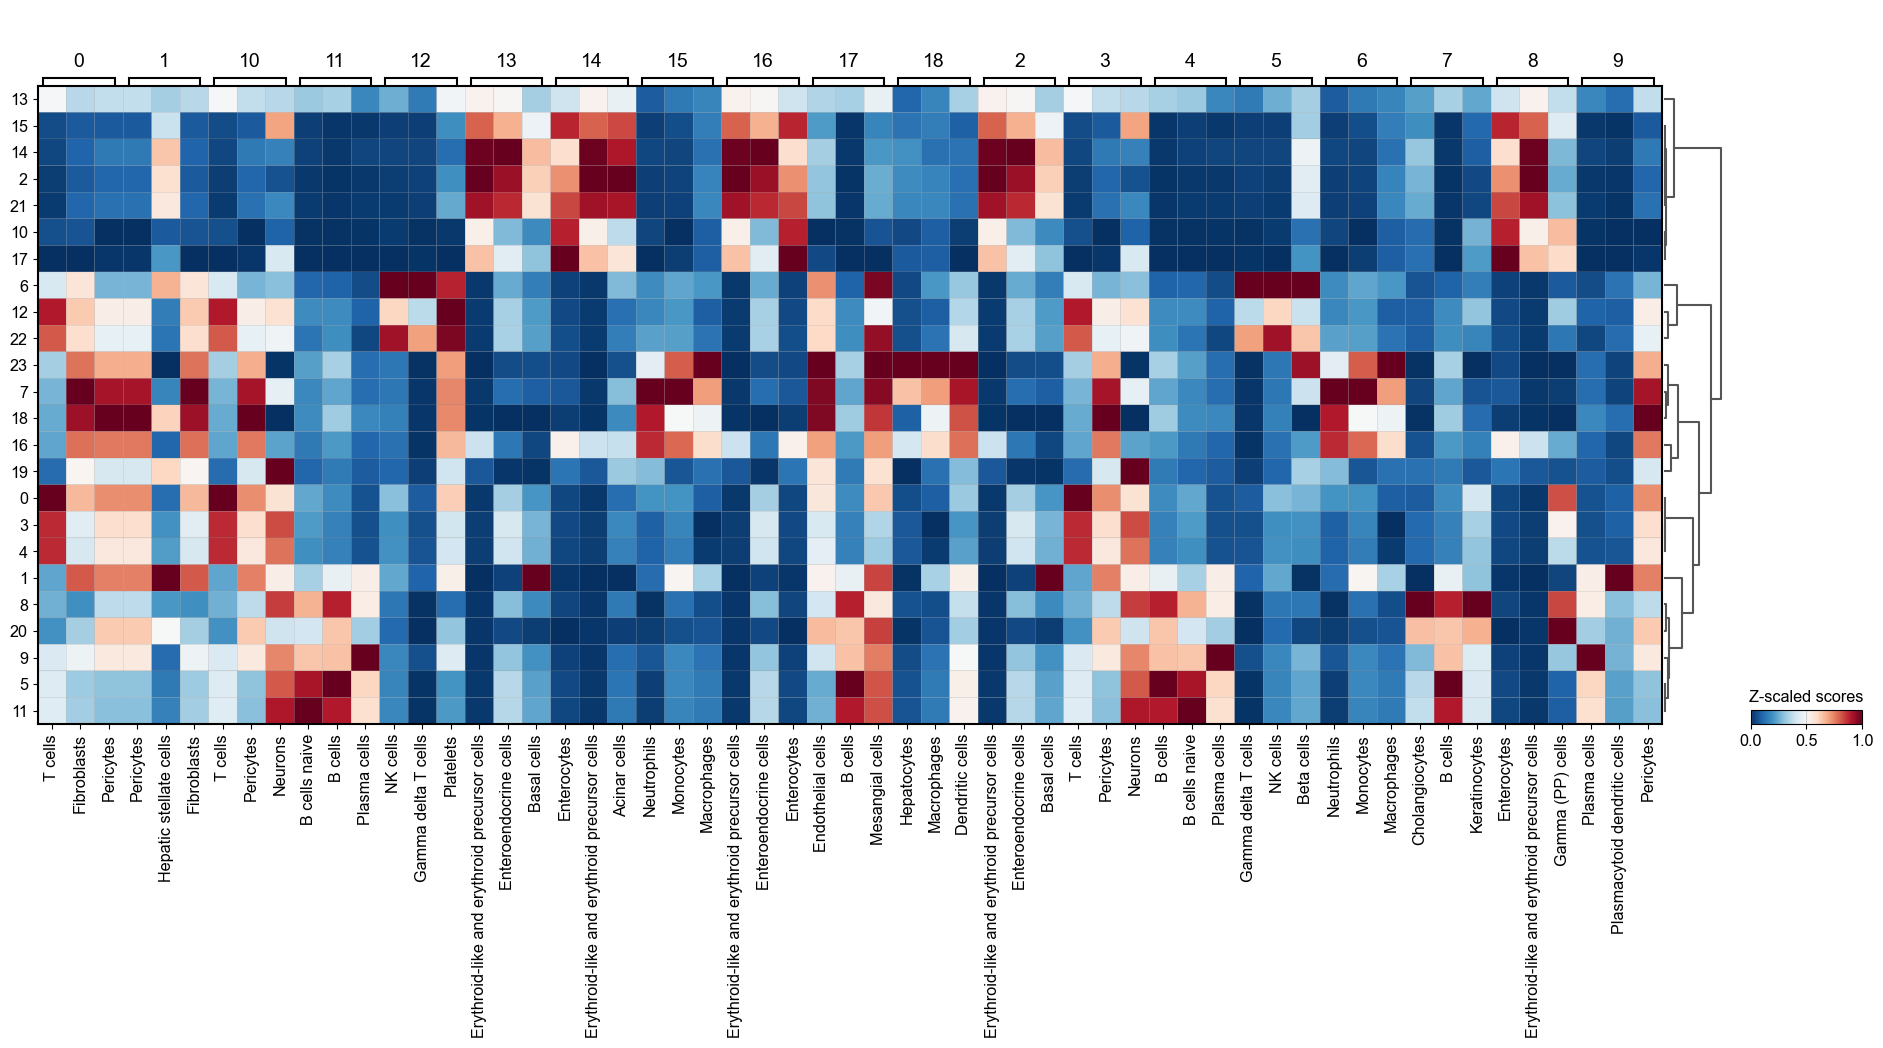

In [77]:
sc.pl.matrixplot(
    adata=score,
    var_names=ctypes_dict,
    groupby="leiden",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

2026-03-05 17:30:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-05 17:30:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-05 17:30:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-05 17:30:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-05 17:30:42 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

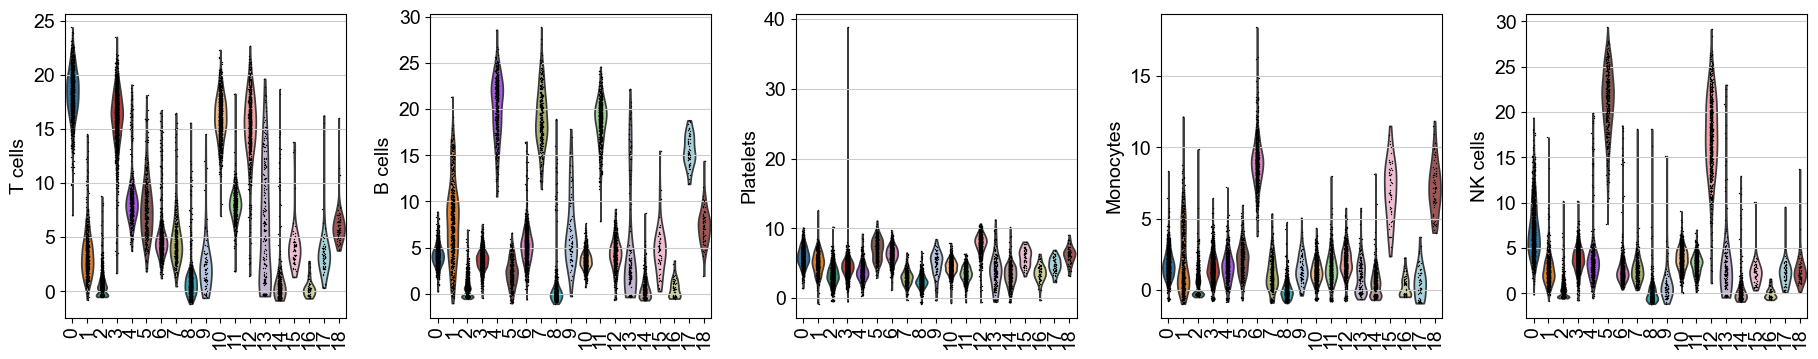

In [78]:
sc.pl.violin(
    adata=score,
    keys=["T cells", "B cells", "Platelets", "Monocytes", "NK cells"],
    groupby="leiden_res_0.50",
    rotation=90,
)

In [86]:
dict_ann = df[df["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
dict_ann

/var/folders/yp/rq67n9wd35vfkdbx07pvj2k80000gp/T/ipykernel_19535/1491444522.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dict_ann = df[df["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


{'0': 'T cells',
 '1': 'Pericytes',
 '2': 'Erythroid-like and erythroid precursor cells',
 '3': 'T cells',
 '4': 'B cells',
 '5': 'Gamma delta T cells',
 '6': 'Neutrophils',
 '7': 'Cholangiocytes',
 '8': 'Enterocytes',
 '9': 'Plasma cells',
 '10': 'T cells',
 '11': 'B cells naive',
 '12': 'NK cells',
 '13': 'Erythroid-like and erythroid precursor cells',
 '14': 'Enterocytes',
 '15': 'Neutrophils',
 '16': 'Erythroid-like and erythroid precursor cells',
 '17': 'Endothelial cells',
 '18': 'Hepatocytes'}

In [93]:
from collections import defaultdict

celltype_clusters = defaultdict(list)

for cluster, celltype in dict_ann.items():
    celltype_clusters[celltype].append(cluster)

dict(celltype_clusters)

{'T cells': ['0', '3', '10'],
 'Pericytes': ['1'],
 'Erythroid-like and erythroid precursor cells': ['2', '13', '16'],
 'B cells': ['4'],
 'Gamma delta T cells': ['5'],
 'Neutrophils': ['6', '15'],
 'Cholangiocytes': ['7'],
 'Enterocytes': ['8', '14'],
 'Plasma cells': ['9'],
 'B cells naive': ['11'],
 'NK cells': ['12'],
 'Endothelial cells': ['17'],
 'Hepatocytes': ['18']}

In [95]:
cluster_to_celltype = dict_ann
score.obs["cell_type"] = score.obs["leiden_res_0.50"].map(cluster_to_celltype)

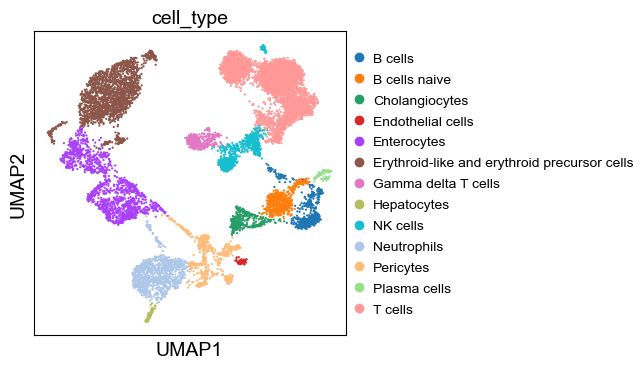

In [98]:
sc.pl.umap(score, color="cell_type")#, legend_loc="on data")

In [87]:
unique_dict = {}
for k, v in dict_ann.items():
    if v not in unique_dict.values():
        unique_dict[k] = v

unique_dict

{'0': 'T cells',
 '1': 'Pericytes',
 '2': 'Erythroid-like and erythroid precursor cells',
 '4': 'B cells',
 '5': 'Gamma delta T cells',
 '6': 'Neutrophils',
 '7': 'Cholangiocytes',
 '8': 'Enterocytes',
 '9': 'Plasma cells',
 '11': 'B cells naive',
 '12': 'NK cells',
 '17': 'Endothelial cells',
 '18': 'Hepatocytes'}

In [ ]:
# Update cats
adata.obs["leiden_res_0.50"] = adata.obs["leiden_res_0.50"].cat.rename_categories()

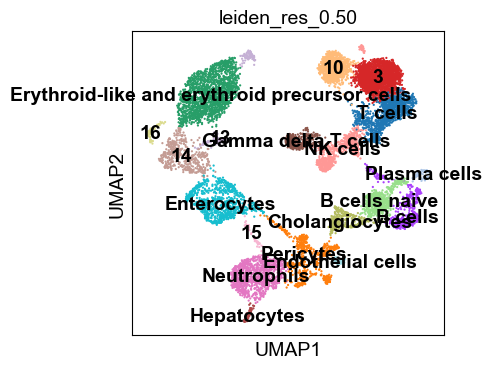

In [92]:
sc.pl.umap(
    adata=adata,
    color=["leiden_res_0.50"],
    ncols=1,
    legend_loc="on data",
)